# BREAST CANCER PREDICTION



# Classification Algorithms
Classification is a supervised machine learning technique used to predict categorical outcomes or class labels based on input data. In classification problems, the target variable belongs to predefined categories such as yes/no, spam/not spam, or malignant/benign. The model learns patterns from labeled training data and uses this knowledge to classify new unseen data. Common classification algorithms include Logistic Regression, K-Nearest Neighbors (KNN), Decision Tree, Random Forest, Naive Bayes, and Support Vector Machine (SVM). These techniques are widely used in applications such as medical diagnosis, fraud detection, email filtering, and customer behavior prediction.


# Explanation of DataSet 

The Breast Cancer Prediction Dataset contains medical and demographic information for 10,000 patients. The purpose of the dataset is to build a Machine Learning classification model that can predict whether a patient is likely to have breast cancer based on the available patient features.

The dataset can be used to practice the complete classification workflow, including data preprocessing, exploratory data analysis (EDA), feature engineering, model training, and evaluation.

🎯 Main Objective

The main objective is:

To predict whether a patient has breast cancer based on different patient-related characteristics.

This is a supervised learning → classification problem, because we have a target variable representing the outcome we want to predict.

📊 What the Dataset Contains

The dataset contains information related to patients, which may include:

Patient demographic information — characteristics such as age or other patient details.
Medical/clinical features — measurements or characteristics associated with the patient's health.
Risk-related factors — variables that may be associated with breast cancer.
Cancer diagnosis/outcome — the target variable that the machine-learning model tries to predict.

# EDA
Exploratory Data Analysis (EDA) is a crucial step in understanding the dataset and uncovering patterns, relationships, and insights. In the context of the Fish dataset, EDA can involve several steps:

### LOADING LIBRARIES 


In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### LOADING DATASET



In [85]:
df= pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\datascience\projects\ML_classification_project\breast_cancer_prediction.csv")
df=df.drop("Annual_Income_USD",axis=1)
df.head(10)


,Patient_ID,Age,Gender,BMI,Family_History,Smoking,Alcohol_Consumption,Physical_Activity,Hormone_Therapy,Menopause_Status,...,Lymph_Node_Involvement,Mammogram_Result,Biopsy_Result,Cancer_Stage,Cancer,Blood_Pressure,Cholesterol,Diabetes,Exercise_Days_Per_Week,Breastfeeding_History
0,100001,71,Female,27.2,Yes,Yes,Yes,High,No,Post,...,No,Suspicious,Malignant,Stage II,1,141,167,No,7,No
1,100002,34,Male,26.0,No,No,No,High,No,Post,...,No,Normal,Benign,No Cancer,0,104,229,Yes,7,Yes
2,100003,80,Female,20.7,No,No,No,High,No,Pre,...,No,Suspicious,Benign,No Cancer,0,161,275,No,1,Yes
3,100004,40,Female,26.8,Yes,Yes,No,Moderate,No,Post,...,No,Normal,Benign,No Cancer,0,150,180,No,7,Yes
4,100005,43,Female,28.6,Yes,Yes,No,Moderate,No,Post,...,No,Normal,Benign,No Cancer,0,110,266,No,0,Yes
5,100006,22,Female,18.8,No,No,No,Moderate,No,Post,...,Yes,Normal,Benign,No Cancer,0,172,270,No,3,Yes
6,100007,41,Female,31.8,Yes,No,Yes,High,No,Post,...,No,Normal,Benign,No Cancer,0,176,297,No,7,No
7,100008,72,Male,23.8,No,Yes,No,High,No,Post,...,No,Normal,Benign,No Cancer,0,164,184,No,5,Yes
8,100009,21,Female,26.1,No,No,No,High,No,Post,...,No,Normal,Benign,No Cancer,0,164,238,No,0,Not Applicable
9,100010,49,Female,29.7,Yes,No,Yes,Moderate,No,Pre,...,No,Normal,Benign,No Cancer,0,177,300,No,0,Yes


#### Cleaning Data And Getting Information About DataSet

In [86]:
df.info()
df.describe()
df.shape
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Patient_ID              10000 non-null  int64  
 1   Age                     10000 non-null  int64  
 2   Gender                  10000 non-null  object 
 3   BMI                     9700 non-null   float64
 4   Family_History          10000 non-null  object 
 5   Smoking                 10000 non-null  object 
 6   Alcohol_Consumption     9700 non-null   object 
 7   Physical_Activity       9700 non-null   object 
 8   Hormone_Therapy         9700 non-null   object 
 9   Menopause_Status        10000 non-null  object 
 10  Genetic_Mutation        10000 non-null  object 
 11  Tumor_Size_cm           9700 non-null   float64
 12  Lymph_Node_Involvement  10000 non-null  object 
 13  Mammogram_Result        10000 non-null  object 
 14  Biopsy_Result           10000 non-null 

Index(['Patient_ID', 'Age', 'Gender', 'BMI', 'Family_History', 'Smoking',
       'Alcohol_Consumption', 'Physical_Activity', 'Hormone_Therapy',
       'Menopause_Status', 'Genetic_Mutation', 'Tumor_Size_cm',
       'Lymph_Node_Involvement', 'Mammogram_Result', 'Biopsy_Result',
       'Cancer_Stage', 'Cancer', 'Blood_Pressure', 'Cholesterol', 'Diabetes',
       'Exercise_Days_Per_Week', 'Breastfeeding_History'],
      dtype='object')

In [87]:
## Checking for null values
df.isnull().sum()

Patient_ID                  0
Age                         0
Gender                      0
BMI                       300
Family_History              0
Smoking                     0
Alcohol_Consumption       300
Physical_Activity         300
Hormone_Therapy           300
Menopause_Status            0
Genetic_Mutation            0
Tumor_Size_cm             300
Lymph_Node_Involvement      0
Mammogram_Result            0
Biopsy_Result               0
Cancer_Stage                0
Cancer                      0
Blood_Pressure              0
Cholesterol                 0
Diabetes                    0
Exercise_Days_Per_Week      0
Breastfeeding_History       0
dtype: int64

In [88]:
#filling null values
df['Alcohol_Consumption'] = df['Alcohol_Consumption'].fillna("Unknown")
df['Physical_Activity'] = df['Physical_Activity'].fillna("Unknown")
df['Hormone_Therapy'] = df['Hormone_Therapy'].fillna("Unknown")
df['BMI'] = df["BMI"].fillna(df['BMI'].mean())
df['Tumor_Size_cm'] = df['Tumor_Size_cm'].fillna(df['Tumor_Size_cm'].mean())
df.isnull().sum()

Patient_ID                0
Age                       0
Gender                    0
BMI                       0
Family_History            0
Smoking                   0
Alcohol_Consumption       0
Physical_Activity         0
Hormone_Therapy           0
Menopause_Status          0
Genetic_Mutation          0
Tumor_Size_cm             0
Lymph_Node_Involvement    0
Mammogram_Result          0
Biopsy_Result             0
Cancer_Stage              0
Cancer                    0
Blood_Pressure            0
Cholesterol               0
Diabetes                  0
Exercise_Days_Per_Week    0
Breastfeeding_History     0
dtype: int64

## Outlier Detection


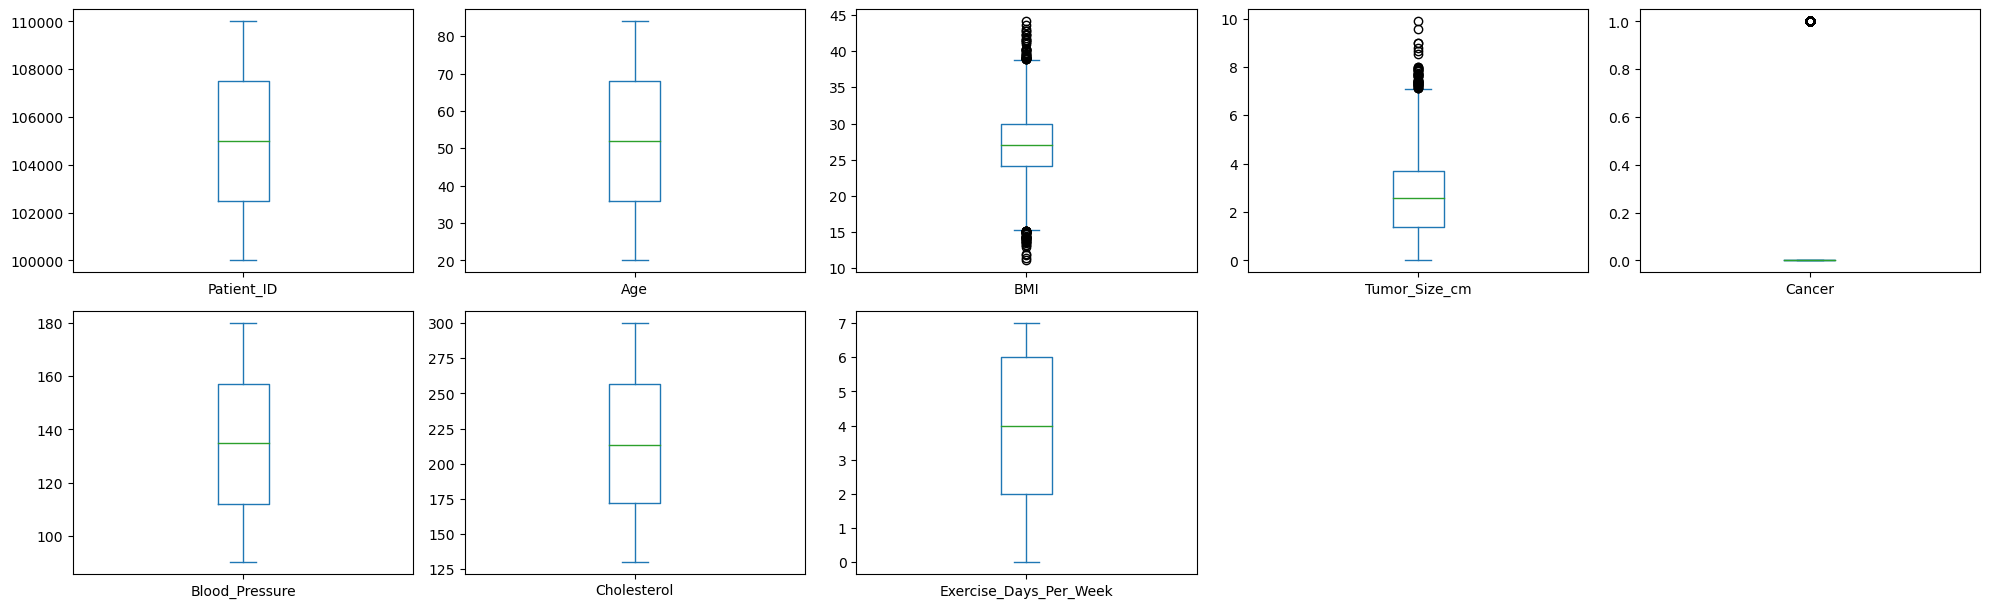

In [89]:
# plot boxplot for checking outliers

# Plot each feature separately
df.plot(
    kind='box',
    subplots=True,
    layout=(5, 5),
    figsize=(20, 15),
    sharex=False,
    sharey=False
)

plt.tight_layout()
plt.show()

In [90]:
outlier_columns = [
    'BMI',
    "Tumor_Size_cm"
]
# Remove outliers using IQR method
for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]

print("Dataset shape after removing outliers:", df.shape)

Dataset shape after removing outliers: (9867, 22)


# Feature Selection
## Target variable is "Cancer"  
#### Independent variables are 'Patient_ID', 'Age', 'Gender', 'BMI', 'Family_History', 'Alcohol_Consumption', 'Physical_Activity', 'Hormone_Therapy','Menopause_Status', 'Genetic_Mutation', 'Tumor_Size_cm','Lymph_Node_Involvement', 'Mammogram_Result', 'Biopsy_Result','Cancer_Stage', Smoking', 'Blood_Pressure', 'Cholesterol', 'Diabetes,'Exercise_Days_Per_Week', 'Breastfeeding_History' . We will use all the independent variables for training our model to predict whether smoking people or non smoking people have breast cancer comparitively

## Classification Algorithms  Used for This Dataset :
##### 1.Logistic Regression
##### 2.K-Nearest Neighbors (KNN)
##### 3.Decision Tree
##### 4.Random Forest
##### 5.Naive Bayes
##### 6.Support Vector Machine (SVM)

--------------

### - Extracting x and y Variables

In [91]:
x=df.drop("Cancer", axis=1)
y=df["Cancer"]
print(y.shape)

(9867,)


### - Categorical Columns

In [92]:
categorical_columns=x.select_dtypes(include=['object','category']).columns.tolist()
print(categorical_columns)

['Gender', 'Family_History', 'Smoking', 'Alcohol_Consumption', 'Physical_Activity', 'Hormone_Therapy', 'Menopause_Status', 'Genetic_Mutation', 'Lymph_Node_Involvement', 'Mammogram_Result', 'Biopsy_Result', 'Cancer_Stage', 'Diabetes', 'Breastfeeding_History']


### -  Encode Categorical Variables

In [93]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct=ColumnTransformer(
    transformers=[("cat",OneHotEncoder(drop="first",sparse_output=False),(categorical_columns))],remainder="passthrough")
x=ct.fit_transform(x)  # Fit the transformer on the feature set and transform

### - Split data into training and testing sets

In [94]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2 ,random_state=42)

### - Standard Scaler

In [95]:
from sklearn.preprocessing import StandardScaler
st_x=StandardScaler()
x_train=st_x.fit_transform(x_train)
x_test = st_x.transform(x_test)

In [104]:
print(y_train)

9039    0
5513    0
2924    0
5229    0
1913    0
       ..
5818    1
5264    0
5467    0
873     1
7372    0
Name: Cancer, Length: 7893, dtype: int64


## Logistic Regression
Logistic Regression is a statistical method used for binary classification problems. It models the relationship between a dependent variable (target) and one or more independent variables (features) by estimating probabilities using a logistic function. The output of logistic regression is a value between 0 and 1, which can be interpreted as the probability of belonging to a particular class. The model is trained using maximum likelihood estimation to find the best-fitting parameters that minimize the difference between predicted probabilities and actual class labels. Logistic regression is widely used in various fields such as healthcare, finance, and social sciences for tasks like disease diagnosis, credit scoring, and customer churn prediction.

In [97]:

# Logistic Regression Model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression()
model.fit(x_train, y_train)

# # Prediction
y_pred = model.predict(x_test)

# # Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


# Random Forest
Random Forest is an ensemble learning method used for classification and regression tasks. It operates by constructing multiple decision trees during training and outputting the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees. The algorithm introduces randomness by selecting random subsets of features and data samples for each tree, which helps to reduce overfitting and improve generalization. Random Forest is known for its robustness, high accuracy, and ability to handle large datasets with many features. It is widely used in various applications such as medical diagnosis, fraud detection, and customer segmentation.

In [98]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model= RandomForestClassifier()

model.fit(x_train,y_train)

y_pred= model.predict(x_test)

print("Accuracy:", accuracy_score(y_test,y_pred))

Accuracy: 1.0


# K-Nearest Neighbors (KNN)
K-Nearest Neighbors (KNN) is a simple and intuitive classification algorithm that classifies new data points based on the majority class of their k nearest neighbors in the feature space. The algorithm calculates the distance between the new data point and all existing data points, identifies the k closest neighbors, and assigns the class label that is most common among those neighbors. KNN is a non-parametric method, meaning it does not make any assumptions about the underlying data distribution. It is widely used for classification tasks such as image recognition, recommendation systems, and anomaly detection due to its simplicity and effectiveness. However, KNN can be computationally expensive for large datasets and may struggle with high-dimensional data.

In [99]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

model = KNeighborsClassifier(n_neighbors=5)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


# Naive Bayes
Naive Bayes is a probabilistic classification algorithm based on Bayes' Theorem, which describes the probability of an event based on prior knowledge of conditions that might be related to the event. The "naive" aspect of the algorithm assumes that all features are independent of each other, which simplifies the computation. Despite this assumption, Naive Bayes often performs well in practice, especially for text classification tasks such as spam detection and sentiment analysis. The algorithm calculates the posterior probability for each class and assigns the class with the highest probability to the new data point. Naive Bayes is known for its simplicity, efficiency, and ability to handle large datasets with high-dimensional features.

In [100]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

model = GaussianNB()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


# Decision Tree
Decision Tree is a supervised learning algorithm used for classification and regression tasks. It works by recursively splitting the data into subsets based on the feature that provides the best separation of classes. The resulting structure resembles a tree, where each internal node represents a feature, each branch represents a decision rule, and each leaf node represents a class label or a regression value. Decision Trees are easy to interpret and visualize, making them popular for understanding the decision-making process. However, they can be prone to overfitting, especially when the tree is deep. To mitigate this issue, techniques such as pruning, setting a maximum depth, or using ensemble methods like Random Forest can be employed. Decision Trees are widely used in various applications such as customer segmentation, medical diagnosis, and credit scoring.

In [101]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

model = GaussianNB()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


# Support Vector Machine (SVM)
Support Vector Machine (SVM) is a powerful supervised learning algorithm used for classification and regression tasks. It works by finding the optimal hyperplane that separates data points of different classes in the feature space. The hyperplane is chosen to maximize the margin, which is the distance between the hyperplane and the nearest data points from each class, known as support vectors. SVM can handle both linear and non-linear classification problems by using kernel functions to transform the data into a higher-dimensional space where a linear separation is possible. SVM is widely used in various applications such as image recognition, text classification, and bioinformatics due to its effectiveness in high-dimensional spaces and its ability to model complex relationships between features.

In [102]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Create model
model = SVC()

# Train model
model.fit(x_train, y_train)

# Prediction
y_pred = model.predict(x_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


## Conclusion

In this breast cancer prediction project, six different Machine Learning classification algorithms—Logistic Regression, K-Nearest Neighbors (KNN), Decision Tree, Random Forest, Naive Bayes, and Support Vector Machine (SVM)—were implemented and evaluated.

All six models achieved an accuracy of 100% (1.00) on the test dataset. This indicates that each of the implemented algorithms correctly classified all observations in the evaluated test set. Therefore, based on accuracy, all six models demonstrated excellent classification performance for this dataset.

The results show that the dataset contains strong patterns that can be effectively learned by different classification techniques. Since all models produced the same accuracy, there is no single best model based on accuracy alone.

However, because this is a breast cancer prediction problem, accuracy alone should not be the only criterion for selecting a final model. Additional evaluation using precision, recall, F1-score, confusion matrix, and ROC-AUC would provide a more comprehensive assessment. In particular, recall is important because correctly identifying actual cancer cases is critical.

Finally, the 100% accuracy should be validated carefully using cross-validation and by checking for possible data leakage or an overly easy test split before considering the models suitable for real-world medical prediction.

##  Table-wise Conclusion

| Algorithm | Accuracy | Conclusion |
|---|---:|---|
| Logistic Regression | 100% | Perfect classification on the evaluated test set. |
| KNN | 100% | Correctly classified all test observations. |
| Decision Tree | 100% | Achieved perfect test accuracy. |
| Random Forest | 100% | Achieved perfect test accuracy. |
| Naive Bayes | 100% | Correctly classified all test observations. |
| SVM | 100% | Achieved perfect test accuracy. |
